# Day 16 - Matplotlib Basics
### India Population Data Visualization

---

**What you will learn today:**
- What is Matplotlib and why do we use it
- Numerical vs Categorical data - the most important concept before plotting
- How to choose the right chart for your data
- Line Plot, Scatter Plot, Bar Chart, Histogram, Pie Chart
- How to style, label, and save your charts professionally

---

## Why Matplotlib?

Imagine you have a table of 10,000 rows of India population data. Can you look at those numbers and immediately understand the trend? No.

But if I show you a line chart - you see the trend in 2 seconds.

**That is the entire job of data visualization** - to make data understandable at a glance.

Matplotlib is the foundational plotting library in Python. Every other library (Seaborn, Plotly, Pandas .plot()) is built on top of Matplotlib. So if you understand Matplotlib, everything else becomes easy.

Think of Matplotlib like MS Paint for data. Seaborn is like Canva - nicer, but underneath it is still doing what Matplotlib does.

## The Most Important Concept: Numerical vs Categorical Data

Before you plot anything, you must ask yourself: **what type of data do I have?**

This one question determines which chart you should use.

---

### Numerical Data (also called Quantitative)

Numbers that have mathematical meaning. You can add, subtract, average them.

Examples:
- India's population in 2020: 138 crore
- Average age of a person: 28.4 years
- GDP per capita: 2100 USD
- Temperature today: 34 degrees

Two types of numerical data:
- **Continuous** - can take any value (height: 5.7 feet, 5.71 feet, 5.712 feet)
- **Discrete** - only whole numbers (number of children: 0, 1, 2, 3)

**Best charts for numerical data:** Line Plot, Histogram, Scatter Plot

---

### Categorical Data (also called Qualitative)

Labels, names, groups. You cannot do math on them.

Examples:
- State names: Maharashtra, UP, Tamil Nadu
- Religion: Hindu, Muslim, Christian, Sikh
- Gender: Male, Female
- Blood Group: A, B, AB, O

**Best charts for categorical data:** Bar Chart, Pie Chart

---

**Golden Rule:**
```
Numerical vs Numerical  ->  Scatter Plot or Line Plot
Category vs Number      ->  Bar Chart or Pie Chart
One Number's distribution -> Histogram
Change over time        ->  Line Plot
```

## Setup - Imports and Folder Creation

We import three things always:
- `matplotlib.pyplot` - the actual plotting functions
- `numpy` - to generate fake but realistic data
- `os` - to create the output folder for saving charts

We use `plt` as the alias because we will type it hundreds of times. Short names save time.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Create a folder to save all our charts
# exist_ok=True means: don't throw an error if folder already exists
os.makedirs('day16_charts', exist_ok=True)

print('Setup complete. Folder created: day16_charts/')

Setup complete. Folder created: day16_charts/


## Matplotlib Styles - Making Charts Look Better

By default, Matplotlib charts look plain. Styles are like themes - they change colors, grid lines, background, fonts all at once.

Popular styles:
- `'ggplot'` - looks like R's ggplot, light gray background
- `'dark_background'` - white text on black, good for presentations
- `'seaborn-v0_8'` - clean and professional
- `'fivethirtyeight'` - bold, journalistic style

In this notebook we will use `seaborn-v0_8-whitegrid` - clean white background with light grid lines. Professional and easy to read.

In [2]:
# See ALL available styles in your Matplotlib version
print('Available styles:')
print(plt.style.available)

Available styles:
['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [3]:
# Apply a style globally - all charts below will use this style
plt.style.use('seaborn-v0_8-whitegrid')

print('Style applied. All charts will now use seaborn-v0_8-whitegrid')

Style applied. All charts will now use seaborn-v0_8-whitegrid


---

# Chart 1: Line Plot - India Population Growth (1950-2023)

## Why Line Plot here?

Our x-axis is **years** (continuous numerical data) and y-axis is **population** (numerical data).

When both axes are numerical AND you want to show how one value **changes over time**, Line Plot is the correct choice.

A line plot literally draws a line connecting your data points - so you can see the direction (going up? going down? fluctuating?).

**Real-world use:** Stock prices, temperature over days, sales over months, website traffic over time - all of these are line plots.

---

## Understanding plt.figure() and plt.plot()

Think of it like this:
- `plt.figure()` = taking out a blank canvas. You set the canvas size here.
- `plt.plot()` = picking up the brush and drawing on that canvas.
- `plt.show()` = hanging the painting on the wall (displaying it).
- `plt.savefig()` = saving a photo of the painting to your computer.

**Important rule:** Always call `savefig()` BEFORE `show()`. After `show()`, Matplotlib clears the figure, so nothing gets saved.

In [4]:
# --- DATA ---
# India's approximate population data (in crores) from 1950 to 2023
# np.random.seed(42) ensures we get the same random numbers every time
np.random.seed(42)

years = np.arange(1950, 2024, 5)  # [1950, 1955, 1960, ..., 2020]

# Base population values (realistic) + tiny random noise to make it look real
base_population = [36, 39, 44, 50, 55, 62, 69, 77, 85, 94, 103, 111, 118, 125, 132]
noise = np.random.uniform(-0.5, 0.5, len(base_population))
population = np.array(base_population) + noise

print('Years:', years)
print('Population (crore):', np.round(population, 1))

Years: [1950 1955 1960 1965 1970 1975 1980 1985 1990 1995 2000 2005 2010 2015
 2020]
Population (crore): [ 35.9  39.5  44.2  50.1  54.7  61.7  68.6  77.4  85.1  94.2 102.5 111.5
 118.3 124.7 131.7]


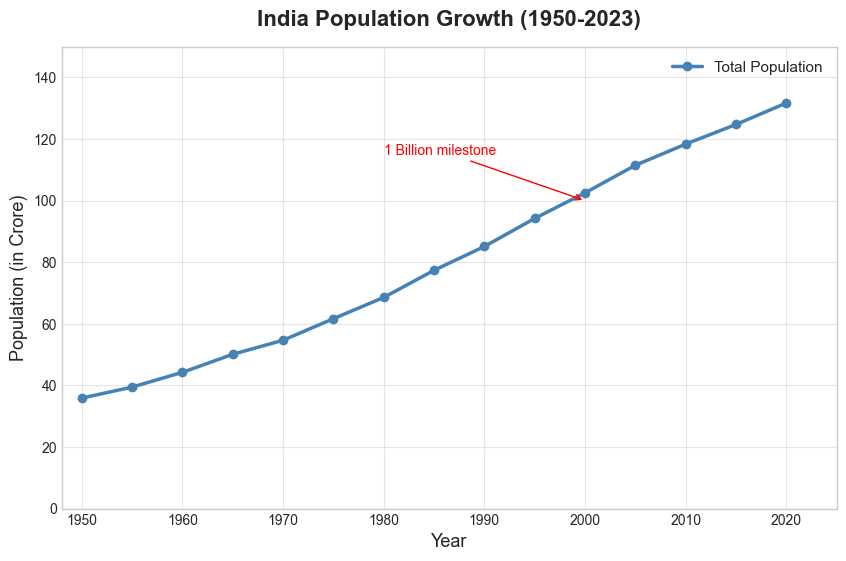

Line plot saved successfully!


In [5]:
# --- PLOTTING ---

# Step 1: Create a blank canvas (figure)
# figsize=(width, height) in inches. 10x6 is a standard landscape size.
plt.figure(figsize=(10, 6))

# Step 2: Draw the line
# color       - any color name or hex code like '#FF5733'
# linestyle   - '-' solid, '--' dashed, ':' dotted, '-.' dash-dot
# linewidth   - thickness of the line
# marker      - shape at each data point: 'o' circle, 's' square, '^' triangle
# markersize  - size of each marker
# label       - text shown in the legend for this line
plt.plot(
    years,
    population,
    color='steelblue',
    linestyle='-',
    linewidth=2.5,
    marker='o',
    markersize=6,
    label='Total Population'
)

# Step 3: Add labels and title
# These are like the title and axis captions of a chart in a newspaper
plt.title('India Population Growth (1950-2023)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=13)
plt.ylabel('Population (in Crore)', fontsize=13)

# Step 4: Set axis limits
# xlim and ylim control the range shown on each axis
# Without this, Matplotlib auto-scales but sometimes cuts off data at edges
plt.xlim(1948, 2025)
plt.ylim(0, 150)

# Step 5: Add grid lines for readability
# alpha controls the transparency of grid lines (0=invisible, 1=fully visible)
plt.grid(True, alpha=0.5)

# Step 6: Show legend (the box that says what each line means)
# legend() only works if you set label= in your plot() call
plt.legend(fontsize=11)

# Step 7: Add a text annotation at a specific point
# This is like adding a sticky note to your chart
plt.annotate('1 Billion milestone', xy=(2000, 100), xytext=(1980, 115),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red')

# Step 8: Save BEFORE show
# dpi=150 means 150 dots per inch - good quality image
# bbox_inches='tight' removes extra whitespace around the chart
plt.savefig('day16_charts/1_line_population_growth.png', dpi=150, bbox_inches='tight')

# Step 9: Display the chart
plt.show()
print('Line plot saved successfully!')

### What you just learned about Line Plot:

- `plt.figure(figsize=)` - controls canvas size
- `plt.plot(x, y, color, linestyle, linewidth, marker, markersize, label)` - the main function
- `plt.title()`, `plt.xlabel()`, `plt.ylabel()` - always add these. A chart without labels is useless.
- `plt.xlim()`, `plt.ylim()` - control the visible range
- `plt.grid(True)` - adds grid lines
- `plt.legend()` - shows what each line means
- `plt.annotate()` - adds arrows and text to highlight specific points
- `plt.savefig()` - saves the chart. Call BEFORE show().

**Common mistake:** Many beginners call `plt.show()` first and then `plt.savefig()`. The saved file will be blank. Always save first.

---

# Chart 2: Scatter Plot - GDP vs Literacy Rate

## Why Scatter Plot here?

We have two numerical variables: GDP per capita and Literacy Rate for different Indian states.

The question we are asking: **Is there a relationship between how rich a state is and how educated its people are?**

Scatter plot is perfect for this because:
- Each dot = one state
- X-position = GDP of that state
- Y-position = Literacy rate of that state
- If dots form a pattern (going up-right), there IS a relationship (correlation)
- If dots are scattered randomly, there is no relationship

**Real-world use:** Height vs Weight, Ad spend vs Revenue, Years of experience vs Salary - all scatter plots.

---

## plt.scatter() vs plt.plot() with marker

Both can draw dots. What is the difference?

- `plt.plot(x, y, marker='o', linestyle='none')` - draws dots but also connects them with a line if you forget linestyle
- `plt.scatter(x, y)` - specifically for scatter plots. More powerful because you can vary the SIZE and COLOR of each dot based on a third variable.

Use `plt.scatter()` when you want to encode a third variable using dot size or color. Otherwise both work.

In [6]:
# --- DATA ---
# Fake but realistic GDP (USD per capita) and Literacy Rate for 20 Indian states
np.random.seed(7)

state_names = [
    'Kerala', 'Delhi', 'Maharashtra', 'Tamil Nadu', 'Karnataka',
    'Gujarat', 'Telangana', 'Andhra Pradesh', 'Punjab', 'West Bengal',
    'Haryana', 'Rajasthan', 'Madhya Pradesh', 'Uttar Pradesh', 'Bihar',
    'Jharkhand', 'Odisha', 'Assam', 'Himachal Pradesh', 'Uttarakhand'
]

gdp_per_capita = np.array([
    2800, 9000, 3200, 2600, 3100,
    3500, 2900, 2100, 3000, 1800,
    3400, 1500, 1300, 1000, 700,
    1200, 1100, 1150, 2500, 2200
])

# Literacy rates roughly correlate with GDP
literacy_rate = np.array([
    94, 88, 84, 82, 77,
    79, 74, 67, 76, 77,
    76, 67, 70, 67, 64,
    67, 73, 73, 83, 79
]) + np.random.uniform(-2, 2, 20)

# Population (in crore) - used to control dot SIZE
# Bigger states = bigger dots. This encodes a 3rd variable visually!
population_size = np.array([
    3.5, 2.0, 12.3, 7.5, 6.5,
    6.3, 3.5, 5.0, 2.8, 9.1,
    2.5, 6.8, 7.3, 20.0, 10.4,
    3.3, 4.2, 3.1, 0.7, 1.0
])

print('Data created for', len(state_names), 'states')

Data created for 20 states


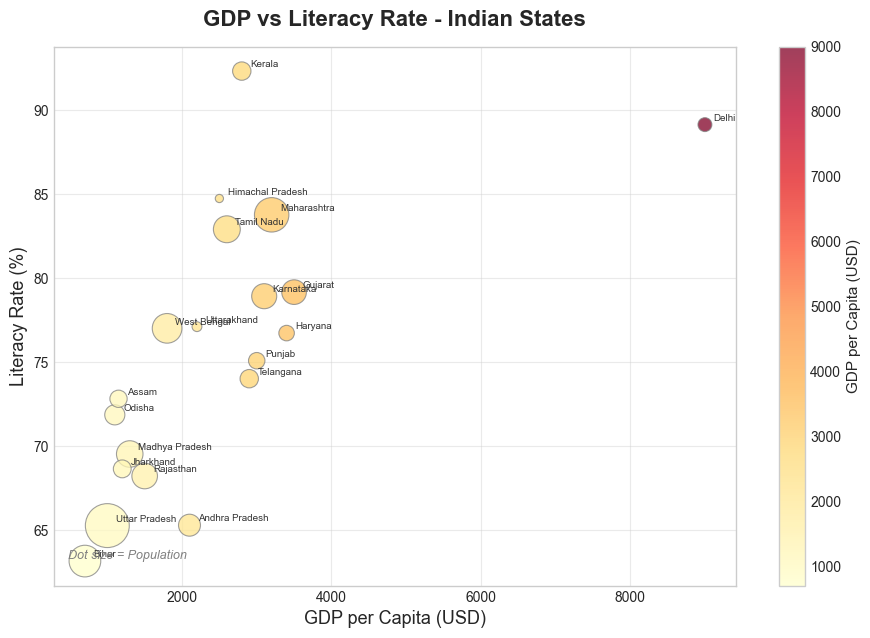

Scatter plot saved!


In [7]:
# --- PLOTTING ---
plt.figure(figsize=(11, 7))

# plt.scatter() parameters:
# x, y    - the two numerical variables
# s       - size of each dot. Here we scale population to get good dot sizes
# c       - color of each dot. Here we use GDP values with a colormap
# cmap    - color map: 'viridis', 'plasma', 'coolwarm', 'Blues', etc.
# alpha   - transparency, helps when dots overlap
# edgecolors - border color around each dot
scatter = plt.scatter(
    gdp_per_capita,
    literacy_rate,
    s=population_size * 50,  # Multiply to make dots a visible size
    c=gdp_per_capita,         # Color encodes GDP (darker = higher GDP)
    cmap='YlOrRd',
    alpha=0.75,
    edgecolors='gray',
    linewidths=0.8
)

# Add colorbar - the legend on the right that explains what color means
cbar = plt.colorbar(scatter)
cbar.set_label('GDP per Capita (USD)', fontsize=11)

# Label every dot with the state name
# We offset the text slightly so it doesn't overlap the dot
for i, state in enumerate(state_names):
    plt.annotate(state, (gdp_per_capita[i], literacy_rate[i]),
                 textcoords='offset points', xytext=(6, 3),
                 fontsize=7, color='#333333')

plt.title('GDP vs Literacy Rate - Indian States', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('GDP per Capita (USD)', fontsize=13)
plt.ylabel('Literacy Rate (%)', fontsize=13)
plt.grid(True, alpha=0.4)

# Add a text note explaining dot size
plt.text(0.02, 0.05, 'Dot size = Population', transform=plt.gca().transAxes,
         fontsize=9, color='gray', style='italic')

plt.savefig('day16_charts/2_scatter_gdp_literacy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Scatter plot saved!')

### What you just learned about Scatter Plot:

- Scatter plot shows **relationship between two numerical variables**
- Each dot is one data point (one state in our case)
- `s=` controls **size** of each dot - you can map a 3rd variable here
- `c=` controls **color** of each dot - you can map a 4th variable here
- `cmap=` is the color palette for the color mapping
- `plt.colorbar()` adds the color legend on the side
- This one chart is showing 4 variables at once: GDP, Literacy, Population, State name!

**Key insight from this chart:** States with higher GDP (right side) generally have higher literacy (top). This positive correlation tells a story - economic development and education go hand in hand.

---

# Chart 3: Bar Chart - Top 5 States by Area

## Why Bar Chart here?

Our x-axis is **state names** (categorical data) and y-axis is **area in sq km** (numerical data).

When one axis is categorical and the other is numerical, Bar Chart is the right choice.

Bar charts are great for **comparison** - you can immediately see which bar is taller (which state is bigger).

**Vertical bars** (`plt.bar`) - used when you have few categories with short names

**Horizontal bars** (`plt.barh`) - used when you have many categories or long names (easier to read labels)

---

## Multiple Bars (Grouped Bar Chart)

When you want to compare two things side by side for each category, you use grouped bars. The trick is using `np.arange()` for positions and manually shifting each group using `width`.

This is slightly tricky, so pay attention to the code.

In [8]:
# --- DATA ---
states = ['Rajasthan', 'Madhya Pradesh', 'Maharashtra', 'Uttar Pradesh', 'Jammu & Kashmir']
area_sqkm = [342239, 308350, 307713, 240928, 222236]  # Real values in sq km

# For grouped bar: forest area vs non-forest area (fake but proportional)
np.random.seed(5)
forest_area = np.array([16.6, 25.1, 16.4, 6.1, 23.0])  # % forest cover (real approx)
agri_area = np.array([50.0, 48.0, 53.0, 60.0, 25.0])    # % agricultural (fake)

print('Data ready')
print('States:', states)
print('Areas (sq km):', area_sqkm)

Data ready
States: ['Rajasthan', 'Madhya Pradesh', 'Maharashtra', 'Uttar Pradesh', 'Jammu & Kashmir']
Areas (sq km): [342239, 308350, 307713, 240928, 222236]


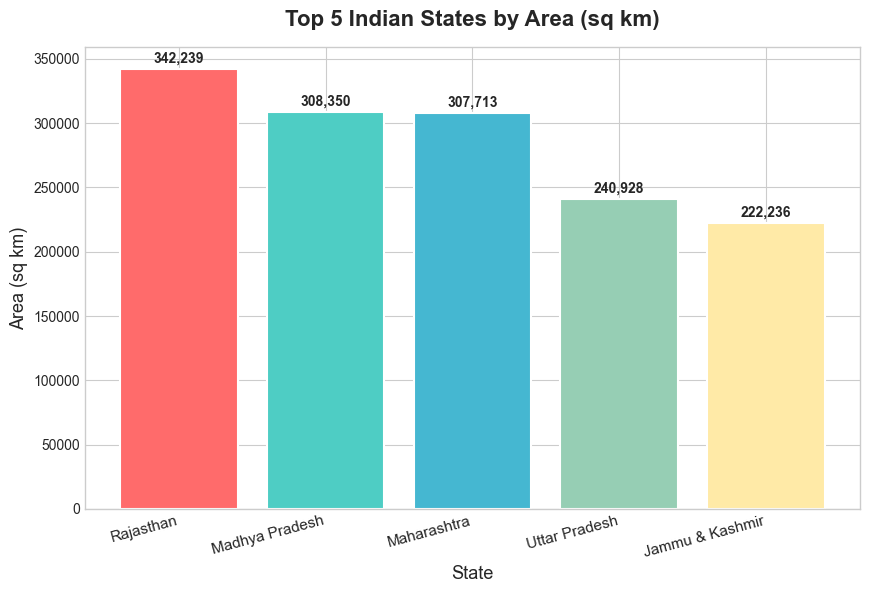

Vertical bar chart saved!


In [9]:
# PART A: Simple vertical bar chart
plt.figure(figsize=(10, 6))

# Custom colors for each bar - makes it visually interesting
bar_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

# plt.bar(x_positions, heights, color)
# x positions can be category labels directly - Matplotlib handles the spacing
bars = plt.bar(states, area_sqkm, color=bar_colors, edgecolor='white', linewidth=1.5)

# Add value labels on top of each bar
# bar.get_height() gives the value (height) of each bar
# bar.get_x() + bar.get_width()/2 gives the center x position of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # x position: center of bar
        height + 3000,                        # y position: just above the bar
        f'{height:,}',                        # text: number with comma formatting
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.title('Top 5 Indian States by Area (sq km)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('State', fontsize=13)
plt.ylabel('Area (sq km)', fontsize=13)

# rotation=15 tilts the x-axis labels so they don't overlap
# ha='right' aligns the rotated text properly
plt.xticks(rotation=15, ha='right', fontsize=11)

plt.savefig('day16_charts/3a_bar_state_area.png', dpi=150, bbox_inches='tight')
plt.show()
print('Vertical bar chart saved!')

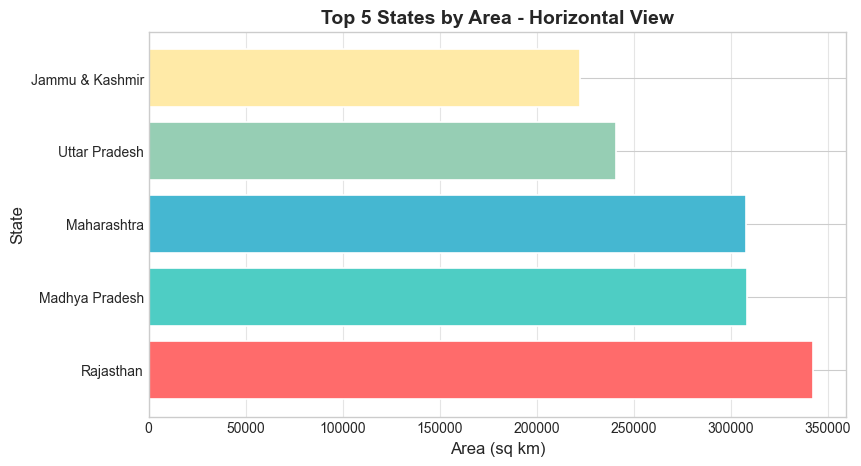

Horizontal bar chart saved!


In [10]:
# PART B: Horizontal bar chart
# Good when labels are long and would overlap on x-axis
plt.figure(figsize=(9, 5))

# plt.barh() - horizontal bars. x and y roles are SWAPPED
# First argument = y-axis (categories), Second argument = x-axis (values)
plt.barh(states, area_sqkm, color=bar_colors, edgecolor='white', linewidth=1.2)

plt.title('Top 5 States by Area - Horizontal View', fontsize=14, fontweight='bold')
plt.xlabel('Area (sq km)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.grid(axis='x', alpha=0.5)  # grid only on x-axis for horizontal charts

plt.savefig('day16_charts/3b_bar_horizontal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Horizontal bar chart saved!')

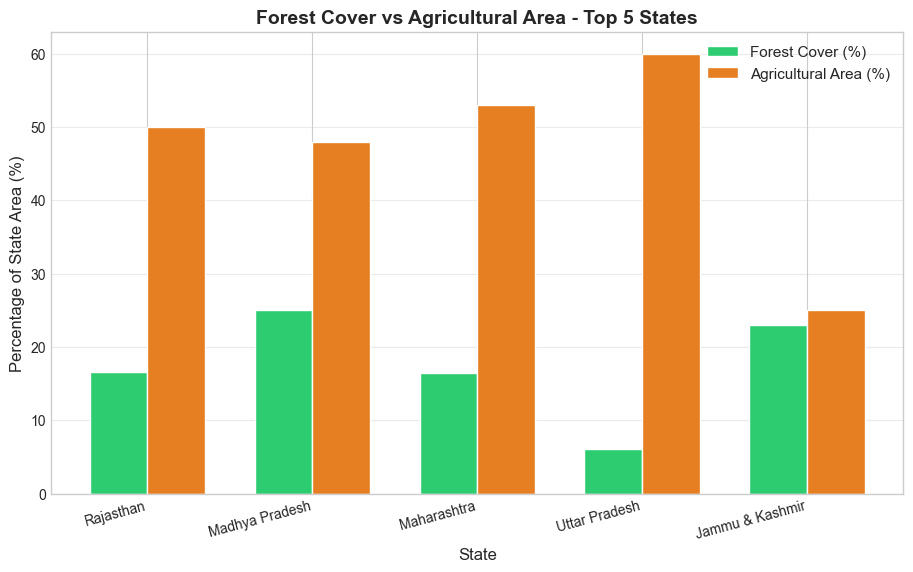

Grouped bar chart saved!


In [11]:
# PART C: Grouped bar chart (two bars per state - side by side)
# This is the trickiest part - pay attention!

plt.figure(figsize=(11, 6))

# How grouped bars work:
# Imagine each state occupies a 'slot' on the x-axis.
# np.arange gives us slot positions: [0, 1, 2, 3, 4]
# We shift the first bar LEFT by half a width
# We shift the second bar RIGHT by half a width
# Result: two bars sit side by side in each slot

x = np.arange(len(states))  # [0, 1, 2, 3, 4] - one slot per state
width = 0.35                 # width of each bar

bars1 = plt.bar(x - width/2, forest_area, width, label='Forest Cover (%)',
                color='#2ecc71', edgecolor='white', linewidth=1)
bars2 = plt.bar(x + width/2, agri_area, width, label='Agricultural Area (%)',
                color='#e67e22', edgecolor='white', linewidth=1)

plt.title('Forest Cover vs Agricultural Area - Top 5 States', fontsize=14, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Percentage of State Area (%)', fontsize=12)

# plt.xticks() manually sets the x-axis tick positions and labels
# Without this, x-axis would show 0, 1, 2, 3, 4 instead of state names
plt.xticks(x, states, rotation=15, ha='right', fontsize=10)

plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.4)

plt.savefig('day16_charts/3c_bar_grouped.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grouped bar chart saved!')

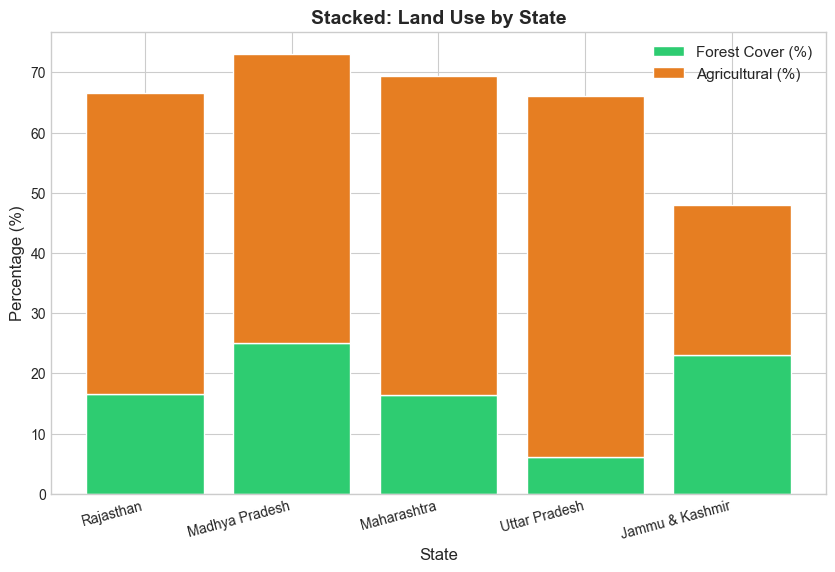

Stacked bar chart saved!


In [12]:
# PART D: Stacked Bar Chart
# Instead of side by side, bars are stacked on top of each other
# Use when you want to show BOTH the individual parts AND the total

plt.figure(figsize=(10, 6))

# First bar starts from 0 (normal)
plt.bar(states, forest_area, label='Forest Cover (%)', color='#2ecc71', edgecolor='white')

# Second bar: bottom=forest_area means this bar starts WHERE the first bar ended
# This is how stacking works - each subsequent bar sits ON TOP of the previous one
plt.bar(states, agri_area, bottom=forest_area, label='Agricultural (%)',
        color='#e67e22', edgecolor='white')

plt.title('Stacked: Land Use by State', fontsize=14, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.legend(fontsize=11)

plt.savefig('day16_charts/3d_bar_stacked.png', dpi=150, bbox_inches='tight')
plt.show()
print('Stacked bar chart saved!')

### What you just learned about Bar Charts:

- `plt.bar(x, y)` - vertical bars. x can be category labels or numbers.
- `plt.barh(x, y)` - horizontal bars. Use when labels are long.
- `color=` - can be a single color or a list of colors (one per bar)
- `edgecolor=` - border color of each bar
- `plt.xticks(positions, labels, rotation=)` - for grouped charts, you must set this manually
- `bottom=` parameter - used in stacked bars. Tells Matplotlib where the bottom of this bar is.
- `np.arange(n)` + `width` trick - used to create side-by-side grouped bars
- Always rotate x-axis labels if they are long: `rotation=15` or `rotation=45`

**When to use stacked vs grouped:**
- Grouped (side by side): easier to compare individual categories
- Stacked: easier to see totals and part-to-whole relationships

---

# Chart 4: Histogram - Age Distribution of India

## Why Histogram here?

A histogram answers the question: **How is this single numerical variable distributed?**

We have ages of many people. We want to know:
- Are most Indians young or old?
- What age group has the most people?

---

## Histogram vs Bar Chart - People always confuse these!

They look similar but they are completely different:

| Bar Chart | Histogram |
|-----------|----------|
| X-axis: categories (labels) | X-axis: numerical ranges (bins) |
| Each bar = one category | Each bar = one bin (range of values) |
| Bars have gaps between them | Bars touch each other (no gap) |
| Counts comparisons between groups | Counts distribution of one variable |

The key is that in a histogram, the **bars touch each other**. This shows that the data is continuous - there is no gap between age 20 and age 21.

---

## What are Bins?

A bin is a range. If you have ages from 0 to 100, you could create bins of size 10:
- Bin 1: 0-10 years
- Bin 2: 10-20 years
- Bin 3: 20-30 years
- ... and so on

Matplotlib counts how many people fall in each bin and draws a bar of that height.

**Too few bins** = you lose detail (everything looks the same)

**Too many bins** = too noisy (hard to see the pattern)

**Rule of thumb:** bins = square root of number of data points. Or just try 10, 20, 30 and see what looks best.

In [13]:
# --- DATA ---
np.random.seed(99)

# India has a young population - median age is ~28
# We simulate this using a mix of two normal distributions
# Most people are in the 15-45 range, with fewer elderly
young_group = np.random.normal(loc=25, scale=8, size=7000)   # young population
middle_group = np.random.normal(loc=45, scale=10, size=2500)  # middle-aged
elderly_group = np.random.normal(loc=65, scale=8, size=500)   # elderly

ages = np.concatenate([young_group, middle_group, elderly_group])

# Clip to realistic age range (0-100)
ages = np.clip(ages, 0, 100)

print(f'Total population sample: {len(ages):,} people')
print(f'Mean age: {ages.mean():.1f} years')
print(f'Median age: {np.median(ages):.1f} years')

Total population sample: 10,000 people
Mean age: 32.2 years
Median age: 29.4 years


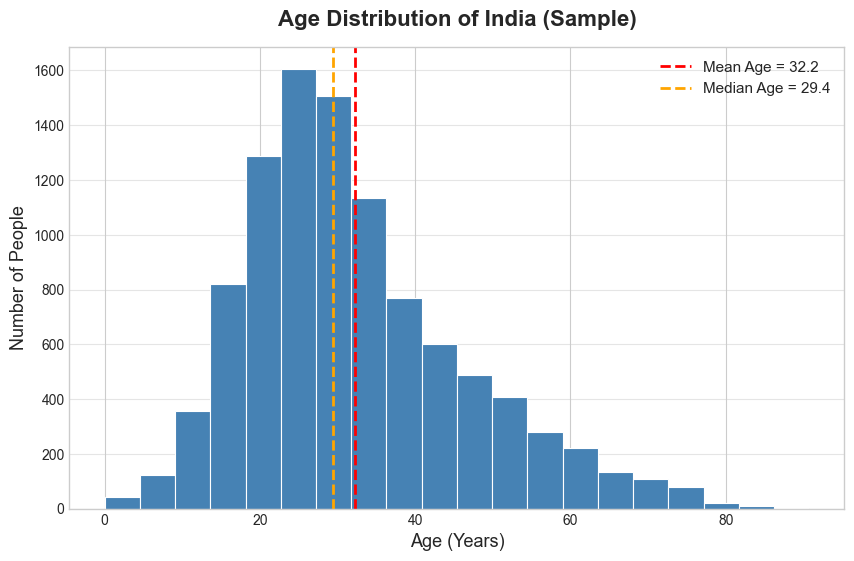

Simple histogram saved!


In [14]:
# PART A: Simple histogram
plt.figure(figsize=(10, 6))

# bins=20 means we divide the data into 20 equal-width ranges
# Matplotlib automatically figures out the bin boundaries
# color and edgecolor work same as bar charts
plt.hist(ages, bins=20, color='steelblue', edgecolor='white', linewidth=0.8)

plt.title('Age Distribution of India (Sample)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Age (Years)', fontsize=13)
plt.ylabel('Number of People', fontsize=13)
plt.grid(axis='y', alpha=0.5)

# Add a vertical line showing the mean age
plt.axvline(x=ages.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean Age = {ages.mean():.1f}')
plt.axvline(x=np.median(ages), color='orange', linestyle='--', linewidth=2, label=f'Median Age = {np.median(ages):.1f}')
plt.legend(fontsize=11)

plt.savefig('day16_charts/4a_histogram_age.png', dpi=150, bbox_inches='tight')
plt.show()
print('Simple histogram saved!')

Custom bin edges: [  0  10  20  30  40  50  60  70  80  90 100]


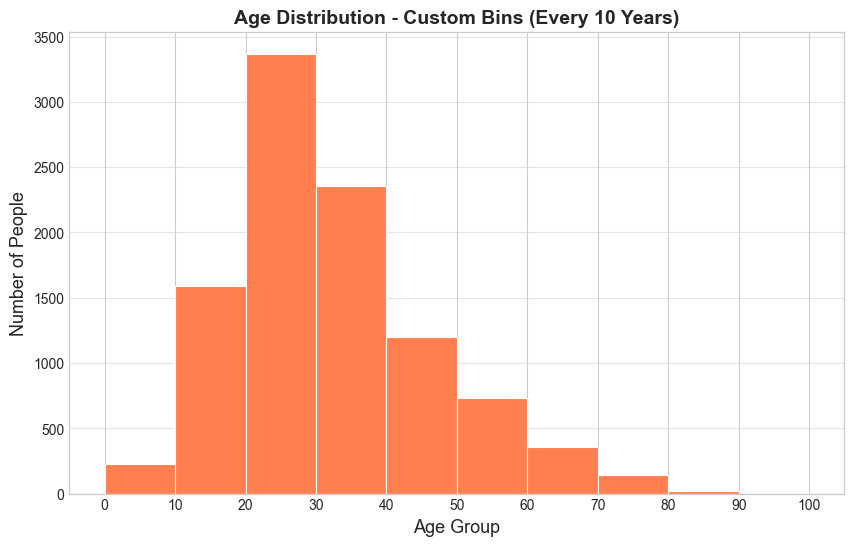

Custom bins histogram saved!


In [15]:
# PART B: Custom bins - you define exact boundaries
# This is useful when you want bins of specific sizes
# np.arange(start, stop, step) creates an array: [0, 10, 20, 30, ...90, 100]
custom_bins = np.arange(0, 101, 10)  # bins of width 10 years each
print('Custom bin edges:', custom_bins)

plt.figure(figsize=(10, 6))

plt.hist(ages, bins=custom_bins, color='coral', edgecolor='white', linewidth=0.8)
plt.title('Age Distribution - Custom Bins (Every 10 Years)', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=13)
plt.ylabel('Number of People', fontsize=13)
plt.xticks(custom_bins)
plt.grid(axis='y', alpha=0.5)

plt.savefig('day16_charts/4b_histogram_custom_bins.png', dpi=150, bbox_inches='tight')
plt.show()
print('Custom bins histogram saved!')

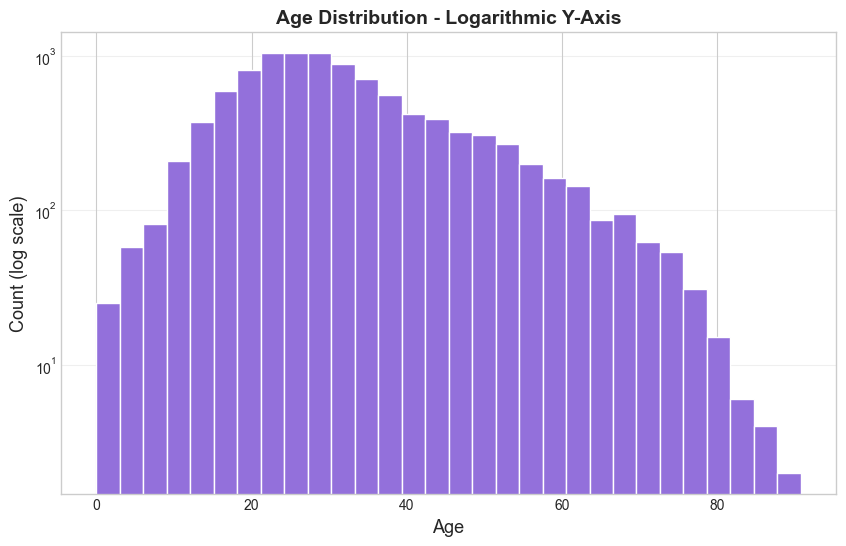

Log histogram saved!


In [16]:
# PART C: log=True
# When your data has very large counts in some bins and very small in others,
# the small bars look flat and invisible.
# log=True changes the y-axis to logarithmic scale.
# Each step is 10x instead of linear (1, 10, 100, 1000...)
# This makes the small bars visible.

plt.figure(figsize=(10, 6))

plt.hist(ages, bins=30, color='mediumpurple', edgecolor='white', log=True)
plt.title('Age Distribution - Logarithmic Y-Axis', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=13)
plt.ylabel('Count (log scale)', fontsize=13)
plt.grid(axis='y', alpha=0.3)

plt.savefig('day16_charts/4c_histogram_log.png', dpi=150, bbox_inches='tight')
plt.show()
print('Log histogram saved!')

### What you just learned about Histograms:

- Histogram shows the **distribution** of one numerical variable
- `bins=` - how many bars. More bins = more detail. Fewer bins = smoother view.
- `bins=custom_array` - you can define exact bin boundaries using an array
- `log=True` - logarithmic y-axis. Use when some bins are tiny compared to others.
- `plt.axvline(x=value)` - draws a vertical line at a specific x position (great for marking mean/median)
- The bars TOUCH each other - this is what distinguishes histogram from bar chart

**Reading a histogram:**
- Tall bars = many data points in that range
- Short bars = few data points
- If most bars are on the LEFT = data is skewed right (most people are young)
- If mostly symmetric = normal distribution (bell curve)

**What our chart tells us:** India has a young population. Most people are in the 15-35 age range. Very few people are above 70 (shorter bars on right side).

---

# Chart 5: Pie Chart - Religion Distribution of India

## Why Pie Chart here?

Pie chart shows **how a whole is divided into parts**. It answers: what percentage of the total does each category represent?

Our data: India's population divided by religion. Total = 100%. Each religion is a slice.

---

## When to use Pie Chart (and when NOT to)

**Use pie chart when:**
- You have 6 or fewer categories
- You want to show part-to-whole relationship
- Percentages add up to 100%
- The differences between slices are large enough to see

**Do NOT use pie chart when:**
- You have many categories (more than 6-7) - slices become tiny and unreadable
- You want to compare exact values - bar chart is better for that
- Slices are very similar in size - human eye cannot tell 32% from 34% in a pie

**Professional tip:** Many data scientists prefer bar charts over pie charts because bar height is easier to compare than slice angle. But pie charts are still widely used in journalism and business presentations for clear, simple stories.

In [17]:
# --- DATA ---
# India Census 2011 approximate religion data
religions = ['Hindu', 'Muslim', 'Christian', 'Sikh', 'Buddhist', 'Others']
percentages = [79.8, 14.2, 2.3, 1.7, 0.7, 1.3]

# Colors chosen to be culturally resonant and visually distinct
colors = ['#FF9933', '#006600', '#0000FF', '#FF6600', '#FFCC00', '#999999']

# explode = how far to pull each slice out from the center
# 0 = no pull, 0.1 = slight pull out
# We highlight Muslim population (index 1) and Christian (index 2) slightly
explode = [0, 0.05, 0.05, 0, 0, 0]

print('Religion data:')
for r, p in zip(religions, percentages):
    print(f'  {r}: {p}%')

Religion data:
  Hindu: 79.8%
  Muslim: 14.2%
  Christian: 2.3%
  Sikh: 1.7%
  Buddhist: 0.7%
  Others: 1.3%


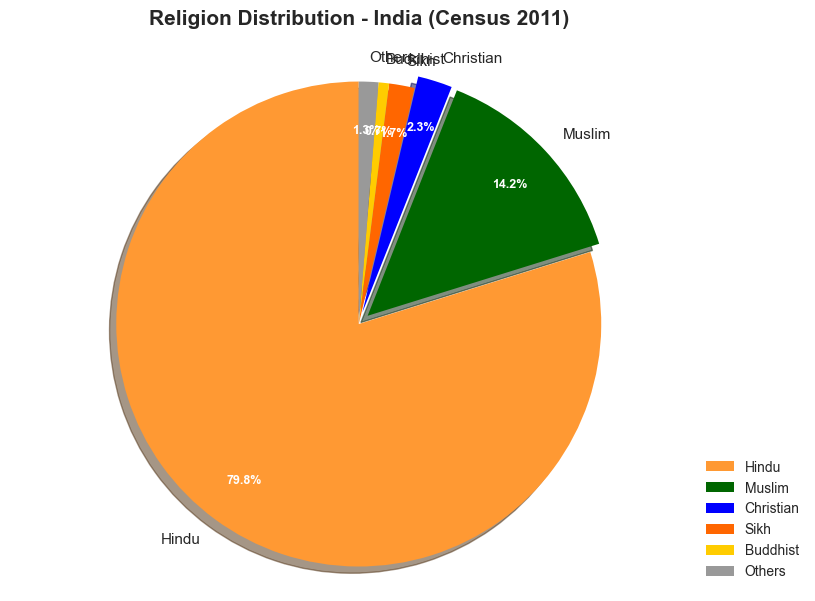

Pie chart saved!


In [18]:
# --- PLOTTING ---
plt.figure(figsize=(9, 7))

# plt.pie() parameters:
# x           - the values (they DON'T need to sum to 100, Matplotlib calculates percentages)
# labels      - text labels for each slice
# autopct     - format string to show percentages inside slices
#               '%1.1f%%' means: 1 digit before decimal, 1 after, followed by %
# colors      - list of colors, one per slice
# explode     - how much to pull each slice outward
# shadow      - adds a shadow under the pie for 3D effect
# startangle  - which angle the first slice starts from (90 = top)
# pctdistance - how far from center to put the percentage text (0.85 = 85% of radius)
# labeldistance - how far from center to put the label text

wedges, texts, autotexts = plt.pie(
    percentages,
    labels=religions,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    shadow=True,
    startangle=90,
    pctdistance=0.80,
    labeldistance=1.1
)

# Style the percentage text inside slices
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

# Style the label text outside slices
for text in texts:
    text.set_fontsize(11)

plt.title('Religion Distribution - India (Census 2011)', fontsize=15, fontweight='bold', pad=20)

# Equal aspect ratio ensures pie is drawn as a circle, not an ellipse
plt.axis('equal')

# Add a legend as well (optional but helpful when labels are crowded)
plt.legend(religions, loc='lower right', fontsize=10, bbox_to_anchor=(1.15, 0))

plt.savefig('day16_charts/5_pie_religion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Pie chart saved!')

### What you just learned about Pie Charts:

- `plt.pie(x, labels, autopct, colors, explode, shadow, startangle)` - the main function
- `autopct='%1.1f%%'` - shows percentages inside slices. `%1.1f` = 1 decimal place float, `%%` = literal % sign
- `explode=` - pull specific slices out to highlight them
- `shadow=True` - adds a shadow for visual depth
- `startangle=90` - start from top (12 o'clock position). Default is 0 (3 o'clock position)
- `plt.axis('equal')` - ALWAYS add this for pie charts. Ensures the pie is a perfect circle.
- `plt.pie()` returns three things: wedges (the slices), texts (label objects), autotexts (percentage objects)
- You can style these objects to change font, color, size of labels

---

# Complete Summary: All 5 Charts in One File

Now let's put everything together in one clean file - this is what you will push to GitHub.

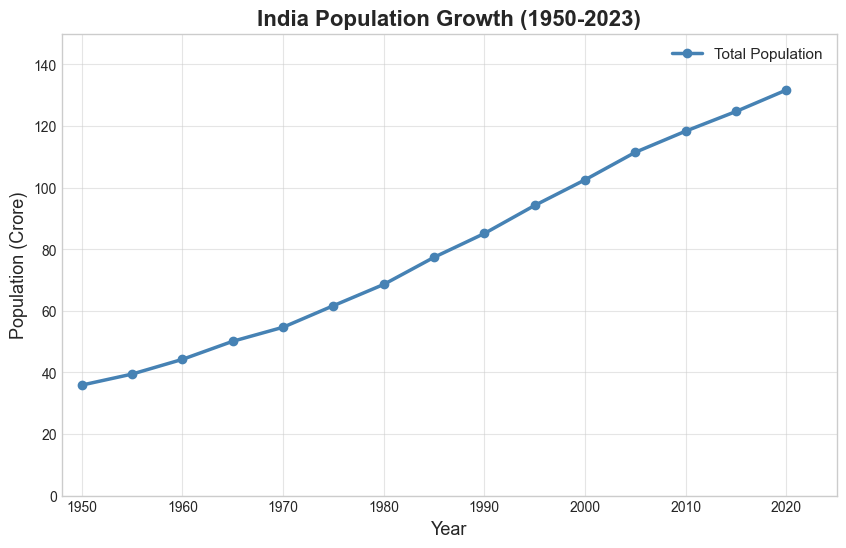

Chart 1 saved


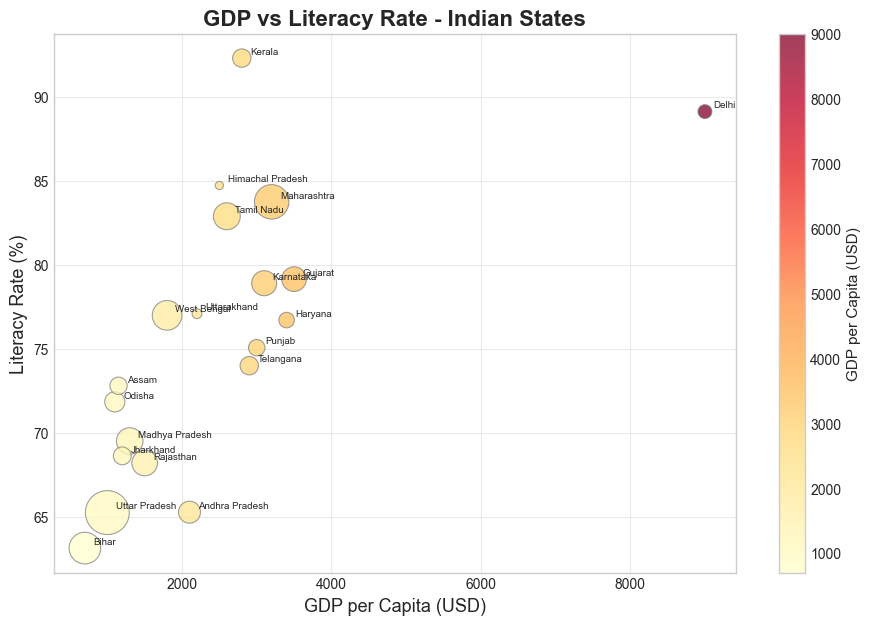

Chart 2 saved


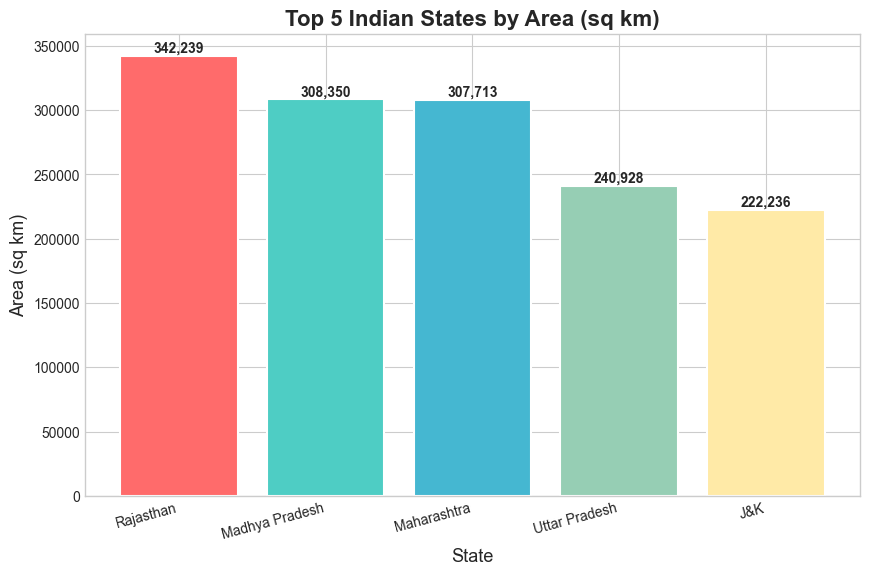

Chart 3 saved


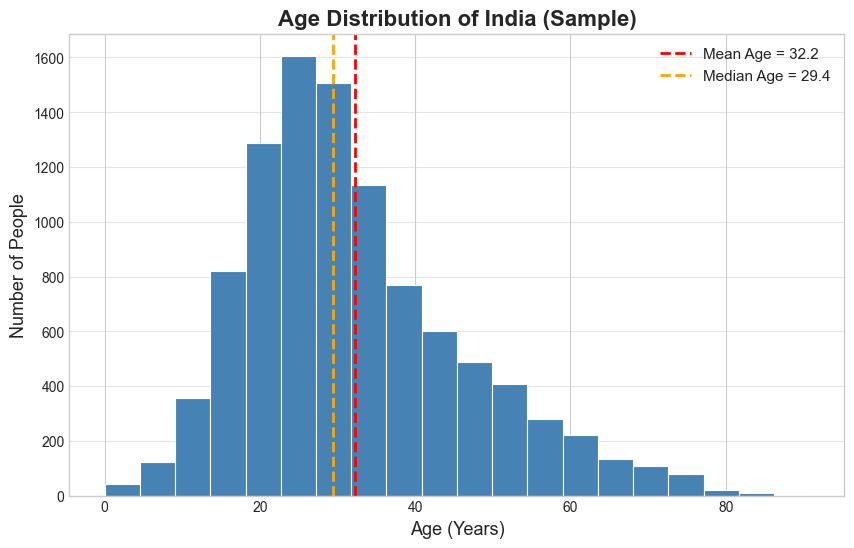

Chart 4 saved


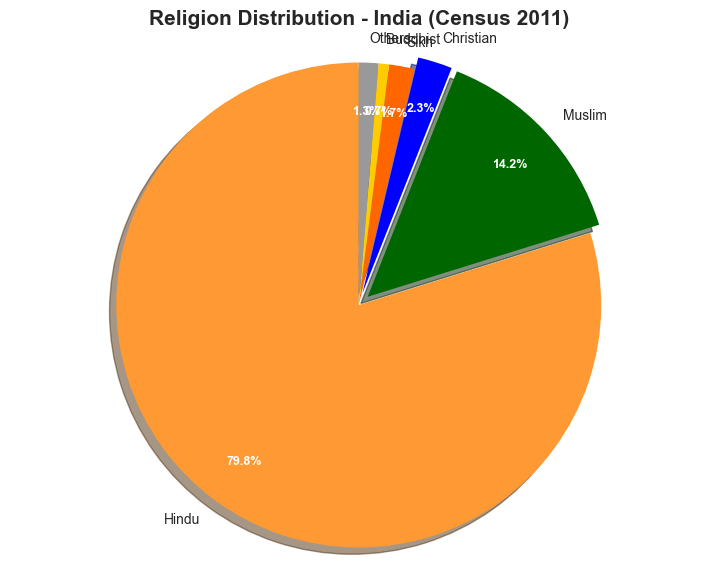

Chart 5 saved

All 5 charts saved in day16_charts/ folder!


In [19]:
# ============================================================
# day16_matplotlib_basics/basics.py
# India Population Data Visualization - 5 Charts
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('day16_charts', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# -------------------------------------------------------
# CHART 1: LINE PLOT - Population Growth
# -------------------------------------------------------
years = np.arange(1950, 2024, 5)
base_pop = [36, 39, 44, 50, 55, 62, 69, 77, 85, 94, 103, 111, 118, 125, 132]
population = np.array(base_pop) + np.random.uniform(-0.5, 0.5, len(base_pop))

plt.figure(figsize=(10, 6))
plt.plot(years, population, color='steelblue', linestyle='-', linewidth=2.5,
         marker='o', markersize=6, label='Total Population')
plt.title('India Population Growth (1950-2023)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=13)
plt.ylabel('Population (Crore)', fontsize=13)
plt.xlim(1948, 2025)
plt.ylim(0, 150)
plt.grid(True, alpha=0.5)
plt.legend(fontsize=11)
plt.savefig('day16_charts/1_line_population_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved')

# -------------------------------------------------------
# CHART 2: SCATTER PLOT - GDP vs Literacy Rate
# -------------------------------------------------------
np.random.seed(7)
states_20 = ['Kerala','Delhi','Maharashtra','Tamil Nadu','Karnataka',
             'Gujarat','Telangana','Andhra Pradesh','Punjab','West Bengal',
             'Haryana','Rajasthan','Madhya Pradesh','Uttar Pradesh','Bihar',
             'Jharkhand','Odisha','Assam','Himachal Pradesh','Uttarakhand']
gdp = np.array([2800,9000,3200,2600,3100,3500,2900,2100,3000,1800,
                3400,1500,1300,1000,700,1200,1100,1150,2500,2200])
literacy = np.array([94,88,84,82,77,79,74,67,76,77,76,67,70,67,64,
                     67,73,73,83,79]) + np.random.uniform(-2,2,20)
pop_size = np.array([3.5,2,12.3,7.5,6.5,6.3,3.5,5,2.8,9.1,
                     2.5,6.8,7.3,20,10.4,3.3,4.2,3.1,0.7,1.0])

plt.figure(figsize=(11, 7))
sc = plt.scatter(gdp, literacy, s=pop_size*50, c=gdp, cmap='YlOrRd',
                 alpha=0.75, edgecolors='gray', linewidths=0.8)
plt.colorbar(sc).set_label('GDP per Capita (USD)', fontsize=11)
for i, s in enumerate(states_20):
    plt.annotate(s, (gdp[i], literacy[i]), textcoords='offset points',
                 xytext=(6,3), fontsize=7)
plt.title('GDP vs Literacy Rate - Indian States', fontsize=16, fontweight='bold')
plt.xlabel('GDP per Capita (USD)', fontsize=13)
plt.ylabel('Literacy Rate (%)', fontsize=13)
plt.grid(True, alpha=0.4)
plt.savefig('day16_charts/2_scatter_gdp_literacy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved')

# -------------------------------------------------------
# CHART 3: BAR CHART - Top 5 States by Area
# -------------------------------------------------------
top5_states = ['Rajasthan', 'Madhya Pradesh', 'Maharashtra', 'Uttar Pradesh', 'J&K']
area = [342239, 308350, 307713, 240928, 222236]
bar_colors = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7']

plt.figure(figsize=(10, 6))
bars = plt.bar(top5_states, area, color=bar_colors, edgecolor='white', linewidth=1.5)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3000,
             f'{bar.get_height():,}', ha='center', fontsize=10, fontweight='bold')
plt.title('Top 5 Indian States by Area (sq km)', fontsize=16, fontweight='bold')
plt.xlabel('State', fontsize=13)
plt.ylabel('Area (sq km)', fontsize=13)
plt.xticks(rotation=15, ha='right')
plt.savefig('day16_charts/3_bar_state_area.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved')

# -------------------------------------------------------
# CHART 4: HISTOGRAM - Age Distribution
# -------------------------------------------------------
np.random.seed(99)
ages = np.clip(
    np.concatenate([
        np.random.normal(25, 8, 7000),
        np.random.normal(45, 10, 2500),
        np.random.normal(65, 8, 500)
    ]), 0, 100
)

plt.figure(figsize=(10, 6))
plt.hist(ages, bins=20, color='steelblue', edgecolor='white', linewidth=0.8)
plt.axvline(ages.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean Age = {ages.mean():.1f}')
plt.axvline(np.median(ages), color='orange', linestyle='--', linewidth=2,
            label=f'Median Age = {np.median(ages):.1f}')
plt.title('Age Distribution of India (Sample)', fontsize=16, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=13)
plt.ylabel('Number of People', fontsize=13)
plt.grid(axis='y', alpha=0.5)
plt.legend(fontsize=11)
plt.savefig('day16_charts/4_histogram_age.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4 saved')

# -------------------------------------------------------
# CHART 5: PIE CHART - Religion Distribution
# -------------------------------------------------------
religions = ['Hindu', 'Muslim', 'Christian', 'Sikh', 'Buddhist', 'Others']
pct = [79.8, 14.2, 2.3, 1.7, 0.7, 1.3]
pie_colors = ['#FF9933','#006600','#0000FF','#FF6600','#FFCC00','#999999']
explode = [0, 0.05, 0.05, 0, 0, 0]

plt.figure(figsize=(9, 7))
wedges, texts, autotexts = plt.pie(
    pct, labels=religions, autopct='%1.1f%%',
    colors=pie_colors, explode=explode,
    shadow=True, startangle=90, pctdistance=0.80
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_color('white')
    at.set_fontweight('bold')
plt.title('Religion Distribution - India (Census 2011)', fontsize=15, fontweight='bold')
plt.axis('equal')
plt.savefig('day16_charts/5_pie_religion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 5 saved')

print('\nAll 5 charts saved in day16_charts/ folder!')

---

# Quick Reference: Which Chart to Use When?

```
Question you are asking                 ->  Chart to use
-------------------------------------------------------
How does X change over time?            ->  Line Plot
Is there a relationship between X & Y? ->  Scatter Plot
How do categories compare?             ->  Bar Chart
How is this variable distributed?      ->  Histogram
What % of the total does each part get? ->  Pie Chart
```

---

# Key Parameters Cheat Sheet

**Common to all charts:**
```python
plt.figure(figsize=(width, height))       # canvas size
plt.title('text', fontsize=16)            # chart title
plt.xlabel('text')                        # x-axis label
plt.ylabel('text')                        # y-axis label
plt.xlim(min, max)                        # x-axis range
plt.ylim(min, max)                        # y-axis range
plt.grid(True, alpha=0.5)                 # grid lines
plt.legend()                              # legend box
plt.savefig('file.png', dpi=150, bbox_inches='tight')  # save
plt.show()                                # display
```

**Line Plot:**
```python
plt.plot(x, y, color, linestyle, linewidth, marker, markersize, label)
```

**Scatter Plot:**
```python
plt.scatter(x, y, s=size, c=color, cmap='colormap', alpha, edgecolors)
```

**Bar Chart:**
```python
plt.bar(x, height, color, edgecolor, width, bottom)    # vertical
plt.barh(y, width, ...)                                 # horizontal
plt.xticks(positions, labels, rotation=)                # for grouped bars
```

**Histogram:**
```python
plt.hist(data, bins=20, color, edgecolor, log=False)
plt.axvline(x=value, color, linestyle)                  # vertical line
```

**Pie Chart:**
```python
plt.pie(x, labels, autopct='%1.1f%%', colors, explode, shadow, startangle)
plt.axis('equal')                                       # always add this
```

---

# What is Next?

Day 17 onwards you will learn:
- Seaborn - beautiful statistical charts built on top of Matplotlib
- Subplots - multiple charts in one figure using `plt.subplot()`
- Pandas `.plot()` - even faster plotting directly from DataFrames
- Plotly - interactive charts you can zoom and hover on

Everything you learned today is the foundation. Once you understand Matplotlib, Seaborn feels like a shortcut and Plotly feels like a superpower.

---